In [8]:
# ==========================================
# Cell 1: Imports and system parameters
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import place_poles

np.set_printoptions(precision=6, suppress=True)

# Physical constants
g = 9.81

# Parameters converted to SI units
m = 0.462          # kg
d = 0.42           # m
delta = 0.65       # m
r = 0.123          # m (not used directly in simulation, but part of system description)

R = 2200           # ohms
L0 = 0.125         # H
L1 = 0.0241        # H
alpha = 1.2        # 1/m
c = 6.811          # magnetic force constant
k = 1885           # N/m
b = 10.4           # Ns/m
phi_deg = 41
phi = np.deg2rad(phi_deg)

tau_m = 0.03       # s

print("Parameters loaded successfully.")
print(f"m = {m} kg")
print(f"d = {d} m")
print(f"delta = {delta} m")
print(f"R = {R} ohms")
print(f"L0 = {L0} H")
print(f"L1 = {L1} H")
print(f"phi = {phi:.4f} rad")
print(f"tau_m = {tau_m} s")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Parameters loaded successfully.
m = 0.462 kg
d = 0.42 m
delta = 0.65 m
R = 2200 ohms
L0 = 0.125 H
L1 = 0.0241 H
phi = 0.7156 rad
tau_m = 0.03 s


In [9]:
# ==========================================
# Cell 2: Nonlinear model
# ==========================================

def nonlinear_model(t, state, u):
    """
    Nonlinear state-space model
    x1 = position
    x2 = velocity
    x3 = current
    x4 = measured position
    """
    x1, x2, x3, x4 = state

    # air gap
    gap = delta - x1
    if gap <= 1e-6:
        gap = 1e-6

    # position-dependent inductance
    Lx = L0 + L1 * np.exp(-alpha * gap)

    # state equations
    x1_dot = x2

    x2_dot = (7 / (5 * m)) * (
        c * (x3**2) / (gap**2)
        - m * g * np.sin(phi)
        - k * (x1 - d)
        - b * x2
    )

    x3_dot = (
        u
        - R * x3
        - alpha * L1 * np.exp(-alpha * gap) * x2 * x3
    ) / Lx

    x4_dot = (x1 - x4) / tau_m

    return [x1_dot, x2_dot, x3_dot, x4_dot]


# quick test
print("Nonlinear model loaded.")

Nonlinear model loaded.


In [10]:
# ==========================================
# Cell 3: Open-loop simulation
# ==========================================

u_open = 5.0  # constant input voltage for open-loop test

initial_state = [0.42, 0.0, 0.0, 0.42]

t_start = 0
t_end = 2
t_eval = np.linspace(t_start, t_end, 1000)

solution_open = solve_ivp(
    fun=lambda t, state: nonlinear_model(t, state, u_open),
    t_span=(t_start, t_end),
    y0=initial_state,
    t_eval=t_eval,
    method='RK45'
)

print("Open-loop simulation success:", solution_open.success)

t_open = solution_open.t
x1_open = solution_open.y[0]
x2_open = solution_open.y[1]
x3_open = solution_open.y[2]
x4_open = solution_open.y[3]

print(f"Final open-loop position = {x1_open[-1]:.6f} m")
print(f"Final open-loop velocity = {x2_open[-1]:.6f} m/s")
print(f"Final open-loop current  = {x3_open[-1]:.6f} A")
print(f"Final measured position  = {x4_open[-1]:.6f} m")

Open-loop simulation success: True
Final open-loop position = 0.418423 m
Final open-loop velocity = 0.000000 m/s
Final open-loop current  = 0.002272 A
Final measured position  = 0.418423 m


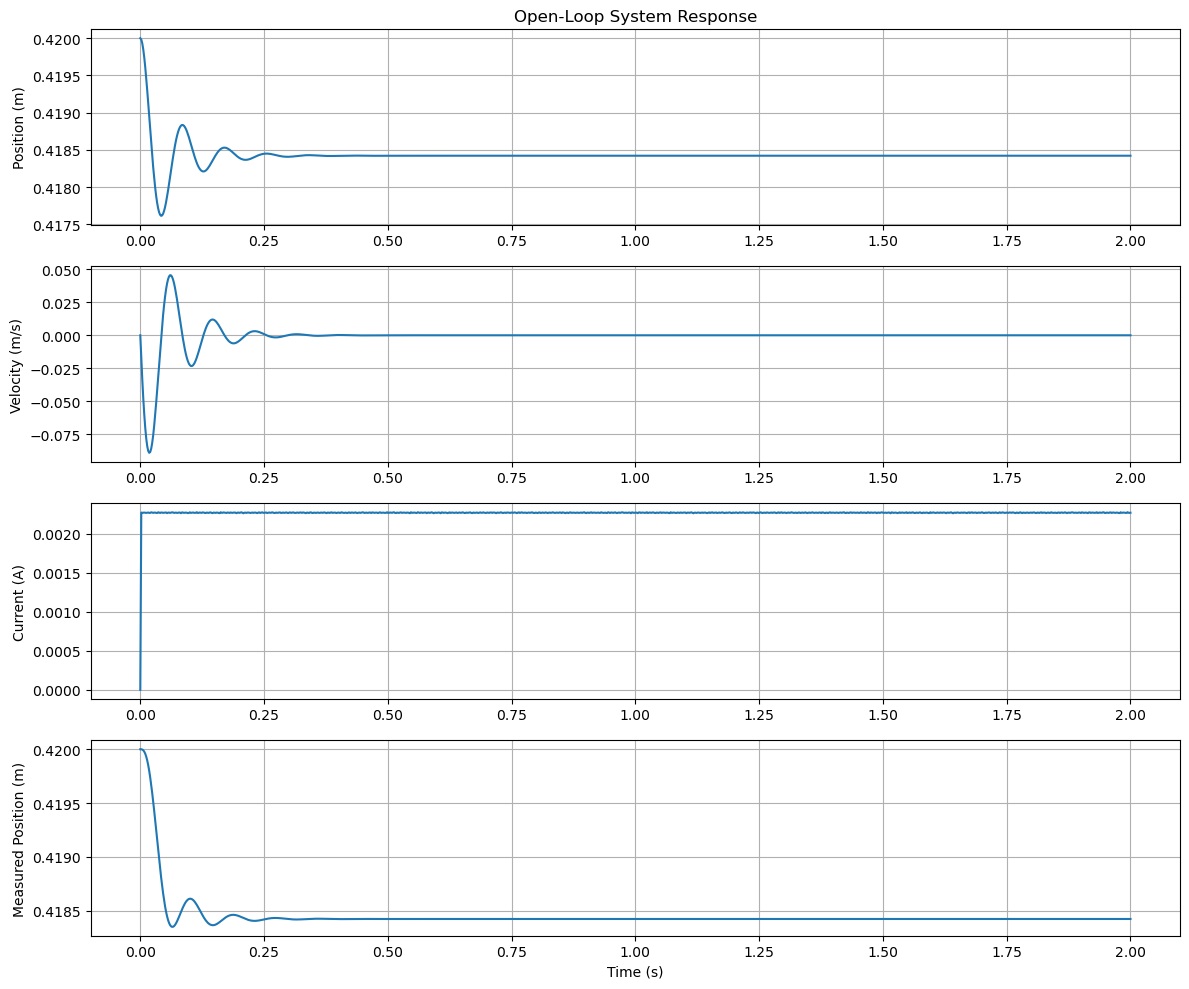

In [11]:
# ==========================================
# Cell 4: Open-loop plots
# ==========================================

plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(t_open, x1_open)
plt.ylabel("Position (m)")
plt.title("Open-Loop System Response")
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(t_open, x2_open)
plt.ylabel("Velocity (m/s)")
plt.grid()

plt.subplot(4, 1, 3)
plt.plot(t_open, x3_open)
plt.ylabel("Current (A)")
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(t_open, x4_open)
plt.ylabel("Measured Position (m)")
plt.xlabel("Time (s)")
plt.grid()

plt.tight_layout()
plt.show()

# Optional save
# plt.savefig("open_loop.png", dpi=300, bbox_inches='tight')

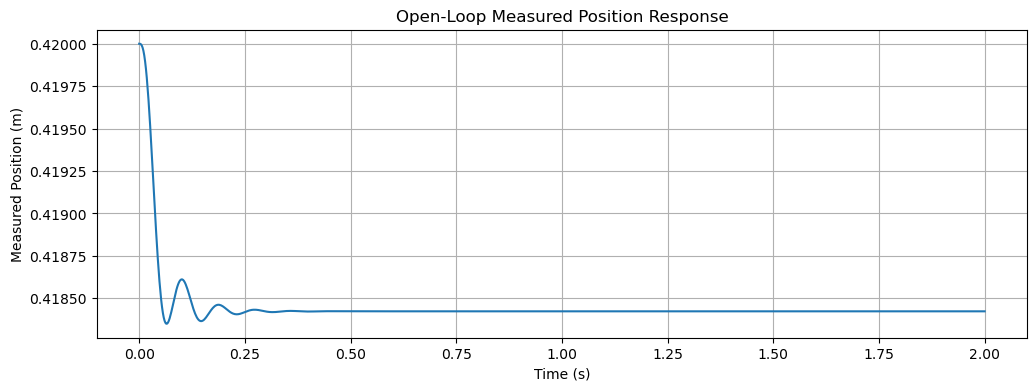

In [12]:
# ==========================================
# Cell 5: Open-loop measured position only
# ==========================================

plt.figure(figsize=(12, 4))
plt.plot(t_open, x4_open)
plt.xlabel("Time (s)")
plt.ylabel("Measured Position (m)")
plt.title("Open-Loop Measured Position Response")
plt.grid()
plt.show()

# Optional save
# plt.savefig("open_loop_position.png", dpi=300, bbox_inches='tight')

In [13]:
# ==========================================
# Cell 6: Equilibrium point
# ==========================================

x_sp = 0.50   # desired reference position

x1_eq = x_sp
x2_eq = 0.0
x4_eq = x1_eq

force_required = m * g * np.sin(phi) + k * (x1_eq - d)

if force_required <= 0:
    raise ValueError("force_required is not positive, equilibrium current cannot be computed.")

gap_eq = delta - x1_eq
x3_eq = np.sqrt(force_required * (gap_eq**2) / c)
u_eq = R * x3_eq

print("Equilibrium values:")
print(f"x1* (position)          = {x1_eq:.6f} m")
print(f"x2* (velocity)          = {x2_eq:.6f} m/s")
print(f"x3* (current)           = {x3_eq:.6f} A")
print(f"x4* (measured position) = {x4_eq:.6f} m")
print(f"u*  (input voltage)     = {u_eq:.6f} V")

Equilibrium values:
x1* (position)          = 0.500000 m
x2* (velocity)          = 0.000000 m/s
x3* (current)           = 0.712732 A
x4* (measured position) = 0.500000 m
u*  (input voltage)     = 1568.011031 V


In [14]:
# ==========================================
# Cell 7: Linearisation
# ==========================================

x_eq = np.array([x1_eq, x2_eq, x3_eq, x4_eq], dtype=float)
u_eq_scalar = float(u_eq)

eps = 1e-6

def f_of_x_u(x, u):
    return np.array(nonlinear_model(0, x, u), dtype=float)

n = len(x_eq)

A = np.zeros((n, n))
B = np.zeros((n, 1))

# A matrix by central difference
for i in range(n):
    dx = np.zeros(n)
    dx[i] = eps
    f_plus = f_of_x_u(x_eq + dx, u_eq_scalar)
    f_minus = f_of_x_u(x_eq - dx, u_eq_scalar)
    A[:, i] = (f_plus - f_minus) / (2 * eps)

# B matrix by central difference
f_plus_u = f_of_x_u(x_eq, u_eq_scalar + eps)
f_minus_u = f_of_x_u(x_eq, u_eq_scalar - eps)
B[:, 0] = (f_plus_u - f_minus_u) / (2 * eps)

C = np.array([[0, 0, 0, 1]], dtype=float)
D = np.array([[0]], dtype=float)

print("A matrix:")
print(A)

print("\nB matrix:")
print(B)

print("\nC matrix:")
print(C)

A matrix:
[[     0.            1.            0.            0.      ]
 [   500.945611    -31.515152   1307.587773      0.      ]
 [     0.           -0.11863  -15158.821861      0.      ]
 [    33.333333      0.            0.          -33.333333]]

B matrix:
[[0.      ]
 [0.      ]
 [6.890374]
 [0.      ]]

C matrix:
[[0. 0. 0. 1.]]


In [15]:
# ==========================================
# Cell 8: Controllability check
# ==========================================

controllability_matrix = B
for i in range(1, A.shape[0]):
    controllability_matrix = np.hstack((controllability_matrix, np.linalg.matrix_power(A, i) @ B))

rank_ctrb = np.linalg.matrix_rank(controllability_matrix)

print("Controllability matrix:")
print(controllability_matrix)

print("\nRank of controllability matrix:", rank_ctrb)
print("Number of states:", A.shape[0])

if rank_ctrb == A.shape[0]:
    print("System is controllable.")
else:
    print("System is NOT fully controllable.")

Controllability matrix:
[[ 0.000000e+00  0.000000e+00  9.009769e+03 -1.368614e+08]
 [ 0.000000e+00  9.009769e+03 -1.368614e+08  2.074670e+12]
 [ 6.890374e+00 -1.044500e+05  1.583337e+09 -2.400151e+13]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  3.003256e+05]]

Rank of controllability matrix: 3
Number of states: 4
System is NOT fully controllable.


In [16]:
# ==========================================
# Cell 9: Augmented system and controller
# ==========================================

A_ctrl = A.copy()
B_ctrl = B.copy()
C_ctrl = C.copy()

Aa = np.block([
    [A_ctrl, np.zeros((4, 1))],
    [-C_ctrl, np.zeros((1, 1))]
])

Ba = np.vstack((B_ctrl, [[0]]))

print("Augmented A matrix:")
print(Aa)

print("\nAugmented B matrix:")
print(Ba)

desired_poles = np.array([-0.5, -1, -2, -3, -4], dtype=float)

Ka = place_poles(Aa, Ba, desired_poles).gain_matrix

print("\nState feedback gain Ka:")
print(Ka)

Acl = Aa - Ba @ Ka
closed_loop_eigs = np.linalg.eigvals(Acl)

print("\nClosed-loop eigenvalues:")
print(closed_loop_eigs)

Augmented A matrix:
[[     0.            1.            0.            0.            0.      ]
 [   500.945611    -31.515152   1307.587773      0.            0.      ]
 [     0.           -0.11863  -15158.821861      0.            0.      ]
 [    33.333333      0.            0.          -33.333333      0.      ]
 [    -0.           -0.           -0.           -1.            0.      ]]

Augmented B matrix:
[[0.      ]
 [0.      ]
 [6.890374]
 [0.      ]
 [0.      ]]

State feedback gain Ka:
[[   -5.97816      0.317404 -2207.887351     2.956532    -0.00004 ]]

Closed-loop eigenvalues:
[-4.  -3.  -2.  -1.  -0.5]


In [17]:
# ==========================================
# Cell 10: Closed-loop linear simulation
# ==========================================

def closed_loop_linear_augmented(t, xa_tilde):
    """
    Linear closed-loop system in deviation variables
    """
    du = -(Ka @ xa_tilde.reshape(-1, 1)).item()

    x_tilde_dot = A_ctrl @ xa_tilde[:4].reshape(-1, 1) + B_ctrl * du
    x5_dot = x_sp - (x4_eq + xa_tilde[3])

    return np.concatenate((x_tilde_dot.flatten(), [x5_dot]))

# initial condition for linear comparison
x1_0 = 0.42
x2_0 = 0.0
x3_0 = 0.0
x4_0 = 0.42
x5_0 = 0.0

xa0_tilde = np.array([
    x1_0 - x1_eq,
    x2_0 - x2_eq,
    x3_0 - x3_eq,
    x4_0 - x4_eq,
    x5_0
], dtype=float)

t_span_cl = (0, 5)
t_eval_cl = np.linspace(0, 5, 1000)

sol_cl = solve_ivp(
    closed_loop_linear_augmented,
    t_span_cl,
    xa0_tilde,
    t_eval=t_eval_cl,
    method='RK45'
)

print("Closed-loop linear simulation success:", sol_cl.success)

t_cl = sol_cl.t
x1_cl = sol_cl.y[0] + x1_eq
x2_cl = sol_cl.y[1] + x2_eq
x3_cl = sol_cl.y[2] + x3_eq
x4_cl = sol_cl.y[3] + x4_eq
x5_cl = sol_cl.y[4]

du_cl = np.array([-(Ka @ sol_cl.y[:, i].reshape(-1, 1)).item() for i in range(sol_cl.y.shape[1])])
u_cl = u_eq + du_cl

Closed-loop linear simulation success: True


In [18]:
# ==========================================
# Cell 11: Closed-loop nonlinear simulation
# ==========================================

def nonlinear_closed_loop(t, z):
    """
    Nonlinear closed-loop system with integral action
    z = [x1, x2, x3, x4, x5]
    """
    x1, x2, x3, x4, x5 = z

    xa_tilde = np.array([
        x1 - x1_eq,
        x2 - x2_eq,
        x3 - x3_eq,
        x4 - x4_eq,
        x5
    ], dtype=float)

    du = -(Ka @ xa_tilde.reshape(-1, 1)).item()

    # actuator saturation on correction term
    du = np.clip(du, -80, 80)

    u = u_eq + du

    x_dot = nonlinear_model(t, [x1, x2, x3, x4], u)
    x5_dot = x_sp - x4

    return np.array([x_dot[0], x_dot[1], x_dot[2], x_dot[3], x5_dot], dtype=float)


z0 = [0.42, 0.0, 0.0, 0.42, 0.0]

sol_nl = solve_ivp(
    nonlinear_closed_loop,
    (0, 5),
    z0,
    t_eval=np.linspace(0, 5, 1000),
    method='Radau',
    max_step=0.01
)

print("Nonlinear closed-loop simulation success:", sol_nl.success)

t_nl = sol_nl.t
x1_nl = sol_nl.y[0]
x2_nl = sol_nl.y[1]
x3_nl = sol_nl.y[2]
x4_nl = sol_nl.y[3]
x5_nl = sol_nl.y[4]

Nonlinear closed-loop simulation success: True


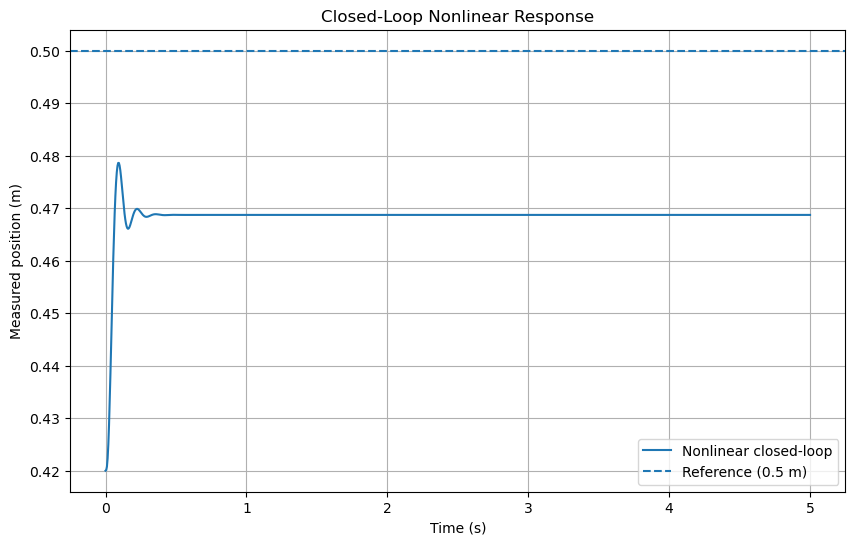

In [19]:
# ==========================================
# Cell 12: Closed-loop nonlinear plot
# ==========================================

plt.figure(figsize=(10, 6))
plt.plot(t_nl, x4_nl, label="Nonlinear closed-loop")
plt.axhline(x_sp, linestyle='--', label="Reference (0.5 m)")
plt.xlabel("Time (s)")
plt.ylabel("Measured position (m)")
plt.title("Closed-Loop Nonlinear Response")
plt.grid()
plt.legend()
plt.show()

# Optional save
# plt.savefig("closed_loop.png", dpi=300, bbox_inches='tight')

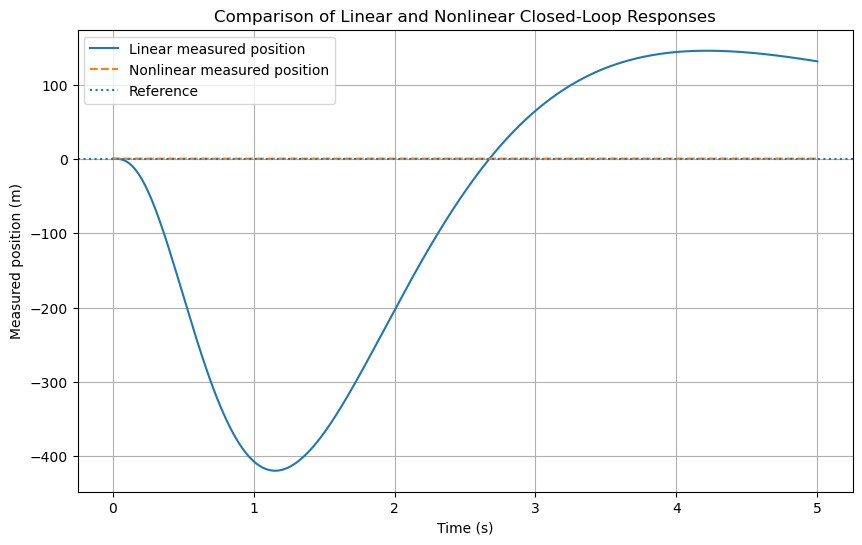

In [20]:
# ==========================================
# Cell 13: Linear vs nonlinear comparison
# ==========================================

plt.figure(figsize=(10, 6))
plt.plot(t_cl, x4_cl, label="Linear measured position")
plt.plot(t_nl, x4_nl, '--', label="Nonlinear measured position")
plt.axhline(x_sp, linestyle=':', label="Reference")
plt.xlabel("Time (s)")
plt.ylabel("Measured position (m)")
plt.title("Comparison of Linear and Nonlinear Closed-Loop Responses")
plt.grid()
plt.legend()
plt.show()

# Optional save
# plt.savefig("comparison.png", dpi=300, bbox_inches='tight')

In [21]:
# ==========================================
# Cell 14: Summary of final results
# ==========================================

print("----- FINAL SUMMARY -----")
print(f"Open-loop final measured position      = {x4_open[-1]:.6f} m")
print(f"Closed-loop nonlinear final position   = {x4_nl[-1]:.6f} m")
print(f"Reference position                     = {x_sp:.6f} m")
print(f"Equilibrium current                    = {x3_eq:.6f} A")
print(f"Equilibrium voltage                    = {u_eq:.6f} V")

----- FINAL SUMMARY -----
Open-loop final measured position      = 0.418423 m
Closed-loop nonlinear final position   = 0.468725 m
Reference position                     = 0.500000 m
Equilibrium current                    = 0.712732 A
Equilibrium voltage                    = 1568.011031 V
